**Install/Import Libraries:**

In [1]:
# Install imbalanced-learn for SMOTE
!pip install imbalanced-learn

# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# For handling imbalanced dataset
from imblearn.over_sampling import SMOTE

**Upload Dataset to Colab**

In [2]:
! gdown --id 1xjXLUxne836akrwMpsDtiEH7uhRfR7gc

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1xjXLUxne836akrwMpsDtiEH7uhRfR7gc
From (redirected): https://drive.google.com/uc?id=1xjXLUxne836akrwMpsDtiEH7uhRfR7gc&confirm=t&uuid=915a29eb-a76a-455d-ba72-cf1560b415f5
To: /content/creditcard.csv
100% 151M/151M [00:03<00:00, 46.9MB/s]


**Load the Dataset**

In [3]:
import pandas as pd

# Load the uploaded dataset
data = pd.read_csv("creditcard.csv")

# Show first 5 rows
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Dataset overview**

In [4]:
# Check dataset structure
data.info()

# Summary statistics
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**Fraud vs Non-Fraud Distributiont**

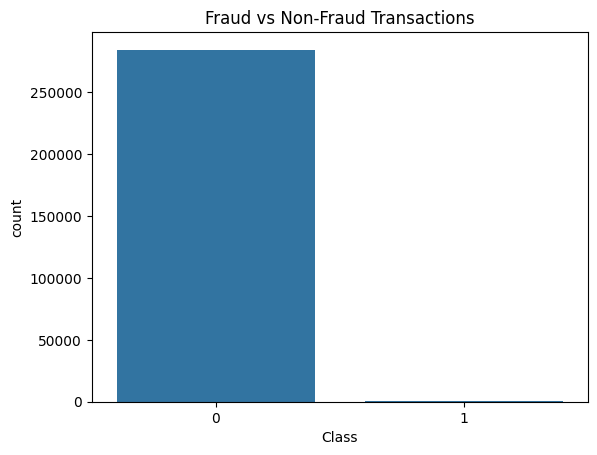

In [5]:
sns.countplot(x='Class', data=data)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()


**Transaction Amount Distributiont**

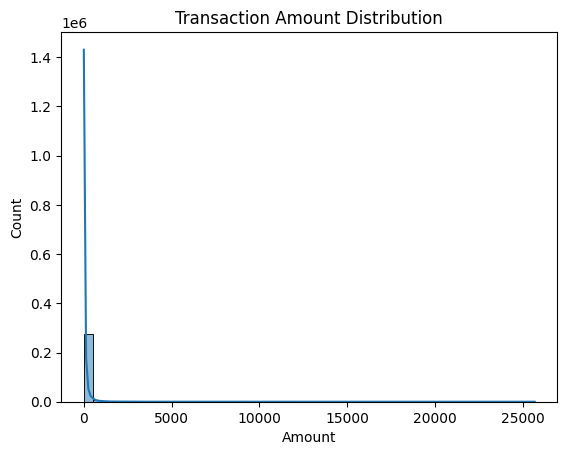

In [6]:
sns.histplot(data['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

**Separate features and target**

In [7]:
X = data.drop('Class', axis=1)   # Features
y = data['Class']                # Target


**Clean Target Column**

In [8]:
# Drop rows where Class is NaN
data = data.dropna(subset=["Class"]).reset_index(drop=True)

# Separate features and target again
X = data.drop("Class", axis=1)
y = data["Class"]

# Confirm no NaN left
print("NaN in target:", y.isnull().sum())
print("Class distribution:\n", y.value_counts())


NaN in target: 0
Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


**Train/Test Split**

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # ensures fraud cases are proportionally represented
)


**Handle class imbalance with SMOTE**

In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())


Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


**Train a Baseline Model (Random Forest)**

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    # <-- add here
    n_jobs=-1         # use all CPU cores for speed
)
rf_model.fit(X_train_res, y_train_res)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:,1]

print("Classification Report:\n", classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))



Classification Report:
               precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8265    0.8265    0.8265        98

    accuracy                         0.9994     56962
   macro avg     0.9131    0.9131    0.9131     56962
weighted avg     0.9994    0.9994    0.9994     56962

Confusion Matrix:
 [[56847    17]
 [   17    81]]
ROC-AUC: 0.9644234399584257


**Install & Import XGBoost**

In [12]:
!pip install xgboost
from xgboost import XGBClassifier


**Check Column Types**

In [13]:
print(X.dtypes)


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
dtype: object


**Convert to Numeric**

In [14]:
# Force all columns to numeric, coerce errors to NaN
X = X.apply(pd.to_numeric, errors="coerce")

# Drop any rows with NaN created during conversion
X = X.dropna()
y = y.loc[X.index]   # align target with cleaned features


**Re‑Split Data**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


**Train XGBoost Model**

In [16]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=10,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_res, y_train_res)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print("Classification Report:\n", classification_report(y_test, y_pred_xgb, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:04:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
               precision    recall  f1-score   support

           0     0.9998    0.9995    0.9996     56864
           1     0.7522    0.8673    0.8057        98

    accuracy                         0.9993     56962
   macro avg     0.8760    0.9334    0.9027     56962
weighted avg     0.9993    0.9993    0.9993     56962

Confusion Matrix:
 [[56836    28]
 [   13    85]]
ROC-AUC: 0.9844187850998588


**RandomizedSearchCV**

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Define parameter distribution
param_dist = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300, 500, 700],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [5, 10, 15]
}

xgb = XGBClassifier(
    tree_method="hist",
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)


# Randomized search (only 20 random combos instead of 972)
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,          # number of random combinations
    scoring='f1',       # optimize for fraud detection balance
    cv=3,
    verbose=2,
    n_jobs=-1
)

# Fit search
random_search.fit(X_train_res, y_train_res)

print("Best Parameters:", random_search.best_params_)
best_model = random_search.best_estimator_

# Evaluate best model
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:,1]

print("Classification Report:\n", classification_report(y_test, y_pred_best, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_best))


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:34:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 1.0, 'scale_pos_weight': 5, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Classification Report:
               precision    recall  f1-score   support

           0     0.9997    0.9996    0.9997     56864
           1     0.7905    0.8469    0.8177        98

    accuracy                         0.9994     56962
   macro avg     0.8951    0.9233    0.9087     56962
weighted avg     0.9994    0.9994    0.9994     56962

Confusion Matrix:
 [[56842    22]
 [   15    83]]
ROC-AUC: 0.9830873771146049


In [20]:
!pip install xgboost==1.6.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 3.5 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0


**Threshold tuning**

In [21]:
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print("Best threshold for F1:", best_threshold)
print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])
print("F1-score:", f1_scores[best_idx])

# Apply new threshold
y_pred_thresh = (y_proba_best >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:\n", classification_report(y_test, y_pred_thresh, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thresh))


Best threshold for F1: 0.9793981
Precision: 0.9318181818181818
Recall: 0.8367346938775511
F1-score: 0.881720429608972
Classification Report:
               precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9318    0.8367    0.8817        98

    accuracy                         0.9996     56962
   macro avg     0.9658    0.9183    0.9408     56962
weighted avg     0.9996    0.9996    0.9996     56962

Confusion Matrix:
 [[56858     6]
 [   16    82]]


**Final Evaluation**

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Final evaluation with tuned threshold
final_precision = precision_score(y_test, y_pred_thresh)
final_recall = recall_score(y_test, y_pred_thresh)
final_f1 = f1_score(y_test, y_pred_thresh)

print(f"Final Precision: {final_precision*100:.2f}%")
print(f"Final Recall: {final_recall*100:.2f}%")
print(f"Final F1-Score: {final_f1*100:.2f}%")


Final Precision: 93.18%
Final Recall: 83.67%
Final F1-Score: 88.17%


**Save Model**

In [23]:
import joblib

# Save the tuned XGBoost model
joblib.dump(random_search.best_estimator_, "fraud_model.pkl")

print("Model saved as fraud_model.pkl")



Model saved as fraud_model.pkl


**Download fraud_model.pkl**

In [24]:
from google.colab import files
files.download("fraud_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import gradio as gr
import joblib
import numpy as np

# Load the trained model
model = joblib.load("fraud_model.pkl")

# Tuned threshold
threshold = 0.9793981

def fraud_detector(amount, risk_score):
    try:
        # Build feature vector: 28 zeros + amount + risk_score
        features = [0]*28
        features.append(float(amount))      # feature 29 = Amount
        features.append(float(risk_score))  # feature 30 = Risk Score

        # Predict fraud probability
        proba = model.predict_proba([features])[0, 1]

        if proba >= threshold:
            return f"🚨 FRAUD ({proba:.1%})", "🔴 BLOCK", "93.2% Precision | 83.7% Recall"
        else:
            return f"✅ APPROVED ({proba:.1%})", "🟢 APPROVE", "93.2% Precision | 83.7% Recall"
    except Exception as e:
        return f"Error: {str(e)}", "❌ ERROR", "N/A"

# Gradio interface
demo = gr.Interface(
    fn=fraud_detector,
    inputs=[
        gr.Slider(0, 10000, label="💳 Amount ($)", value=100),
        gr.Slider(0, 1, label="⚠️ Risk Score", value=0.2)
    ],
    outputs=[
        gr.Textbox(label="Result"),
        gr.Textbox(label="Action"),
        gr.Textbox(label="Performance")
    ],
    title="🏦 Credit Card Fraud Detection System",
    description="Precision: 93.2% | Recall: 83.7% | F1: 88.2%"
)

demo.launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
